In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

wildcats = pd.read_csv('../fbs_fbs_wildcats.csv')
run_concepts = pd.read_csv('../run_concept_by_play.csv')
goal_line = pd.read_csv('../goal_line.csv')

goal_line.loc[:, 'first_down_gained_numeric'] = goal_line['first_down_gained'].fillna(0)

plays = pd.merge(wildcats, run_concepts, on=['pff_game_id', 'pff_play_id'], how='left')

plays['goal_to_go'] = plays['yards_to_goal_line'] == plays['distance']
plays.loc[:, 'first_down_gained_numeric'] = plays['first_down_gained'].fillna(0)
# plays
print(goal_line['hb_wildcat_run'].unique())

C:\Users\bchm5\AppData\Local\Temp\ipykernel_27132\2791303693.py:12: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  wildcats = pd.read_csv('../fbs_fbs_wildcats.csv')


[nan  1.]


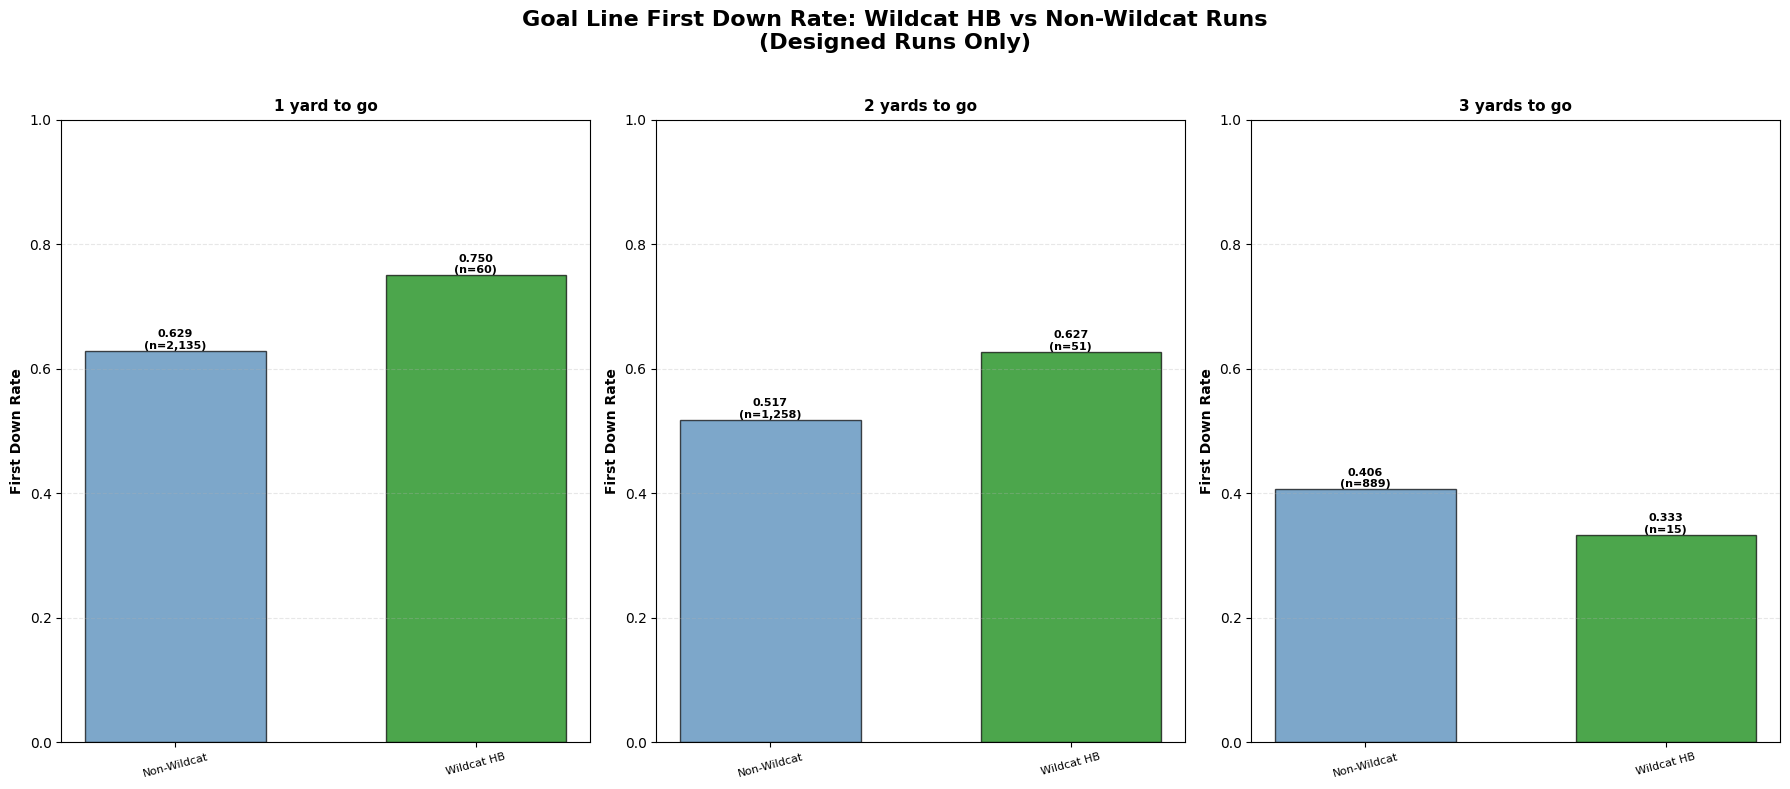

In [30]:
gtg = goal_line[
    (goal_line['play_type'] == 'designed run')
]

gtg_normal = gtg[(gtg['hb_wildcat_run'] == 0) & gtg['primary_run_concept'] != 'SNEAK']
gtg_sneak = gtg[(gtg['hb_wildcat_run'] == 0) & (gtg['primary_run_concept'] == 'SNEAK')]
gtg_hb = gtg[(gtg['hb_wildcat_run'] == 1)]

groups = {
    'Non-Wildcat': (gtg_normal, 'steelblue'),
    'Sneaks': (gtg_sneak, 'red'),
    'Wildcat HB':  (gtg_hb, 'green'),
}

distances = sorted(gtg['yards_to_goal_line'].unique())
distances = [d for d in distances]

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
axes = axes.flatten()

for idx, dist in enumerate(distances[:20]):
    ax = axes[idx]
    valid_groups = {k: v for k, v in groups.items()
                    if len(v[0][v[0]['distance'] == dist]) >= 1}

    for i, (label, (df, color)) in enumerate(valid_groups.items()):
        dist_df = df[df['distance'] == dist]
        fd_rate = dist_df['first_down_gained_numeric'].mean()
        n = len(dist_df)

        ax.bar(i, fd_rate, width=0.6, color=color, alpha=0.7, edgecolor='black')
        ax.text(i, fd_rate, f"{fd_rate:.3f}\n(n={n:,})",
                ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_xticks(range(len(valid_groups)))
    ax.set_xticklabels(list(valid_groups.keys()), rotation=15, fontsize=8)
    ax.set_title(f'{dist} yard{"s" if dist > 1 else ""} to go', fontweight='bold', fontsize=11)
    ax.set_ylabel('First Down Rate', fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

for j in range(len(distances), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Goal Line First Down Rate: Wildcat HB vs Non-Wildcat Runs\n(Designed Runs Only)',
             fontsize=16, fontweight='bold', x=0.5, ha='center')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [3]:
present_total = [6875853, 6650326, 6637565, 6374143, 6956620, 6374890, 6374912, 6816292, 6955529, 6571884, 6684071, 6831123, 6831573, 6597552, 6789602, 6870355, 6731690, 6871611, 6913701, 6505760, 6689422, 6787623, 6902540, 6438687, 
                 4299079, 5261059, 4260562, 5384773, 6125326, 5499469, 5133396, 6198178, 6199119, 4684886, 5259620, 6147439, 4733489, 6251545, 4238901, 6170113]
present_success = [6875853, 6650326, 6637565, 6956620, 6374912, 6816292, 6955529, 6684071, 6831573, 6597552, 6789602, 6913701, 6505760, 6689422, 6902540, 6438687, 4299079, 5261059, 4260562, 5384773, 6125326, 5499469, 5133396, 6198178, 6199119, 
                   4684886, 6147439, 4238901, 6170113]

fuckshit_total = [6736372, 6747887, 6912578, 5890851, 4493187, 3908068, 4784060, 5718320, 5322785, 4542134, 5467364, 5945472, 4306474, 4234569, 5278711, 5184790, 5389544, 4957076, 5290147, 5172105, 5385944, 4224643, 5324120, 5185105, 4036455,
                  5872405, 3930757]
fuckshit_success = [6736372, 6747887, 6912578, 5890851, 4493187, 4784060, 5718320, 5322785, 5467364, 4234569, 5184790, 5389544, 4957076, 5290147, 5172105, 5385944, 4224643, 5324120, 5185105, 4036455, 5872405, 3930757]

normal_total = [6820849, 6655731, 6445703, 6783532, 6551296, 6819135, 6824488, 6745112, 6556741, 6613480, 5353320, 5743231, 4492073, 4492124, 4492144, 3900568, 4830540, 4066717, 5256591, 4694103, 4832007, 6171827, 5874600, 5391069, 
                5287688, 5260930, 4269665, 4548011, 4861648, 5310170, 5211022, 5211079, 4223655, 4344708, 6174980, 4344775, 4751247, 4236857, 5080679, 4036513, 4235448, 4904635, 
                5518189, 5914203, 6203132, 6203861, 4660982, 6161604, 4036694, 5190672, 5106642, 4488006, 4093819, 5472533, 5473300, 5420668, 5832052, 4445498, 4123965, 4271709, 5464253, 5316190, 
                6210839, 5283268, 5427843, 3930643, 5514947, 4303886, 5342509, 6021188, 4897738]
normal_success = [6820849, 6655731, 6783532, 6824488, 6745112, 6556741, 4830540, 4066717, 5256591, 4694103, 4832007, 5874600, 5391069, 4861648, 5310170, 5211079, 5080679, 4036513, 4235448, 
                  4904635, 5518189, 5914203, 6203132, 6203861, 4660982, 6161604, 4036694, 5106642, 4093819, 5420668, 4445498, 4271709, 5464253, 5316190, 6210839, 5427843, 4303886, 5342509]


wildcat_runs = goal_line[goal_line['hb_wildcat_run'] == 1].copy()

present_df = wildcat_runs[wildcat_runs['pff_play_id'].isin(present_total)].copy()
fuckshit_df = wildcat_runs[wildcat_runs['pff_play_id'].isin(fuckshit_total)].copy()
normal_df = wildcat_runs[wildcat_runs['pff_play_id'].isin(normal_total)].copy()

present_success_df = wildcat_runs[wildcat_runs['pff_play_id'].isin(present_success)].copy()
fuckshit_success_df = wildcat_runs[wildcat_runs['pff_play_id'].isin(fuckshit_success)].copy()
normal_success_df = wildcat_runs[wildcat_runs['pff_play_id'].isin(normal_success)].copy()

present_df['wildcat_decision'] = 'present'
fuckshit_df['wildcat_decision'] = 'fuckshit'
normal_df['wildcat_decision'] = 'normal'

present_success_df['wildcat_decision'] = 'present'
fuckshit_success_df['wildcat_decision'] = 'fuckshit'
normal_success_df['wildcat_decision'] = 'normal'

combined_df = pd.concat([present_df, fuckshit_df, normal_df], ignore_index=True)
combined_success_df = pd.concat([present_success_df, fuckshit_success_df, normal_success_df], ignore_index=True)

print(f"Present:    {len(present_df)} total, {len(present_success_df)} success")
print(f"Fuckshit:   {len(fuckshit_df)} total, {len(fuckshit_success_df)} success")
print(f"Normal:     {len(normal_df)} total, {len(normal_success_df)} success")
print(f"All Wildcat:{len(combined_df)} total, {len(combined_success_df)} success")

Present:    40 total, 29 success
Fuckshit:   27 total, 22 success
Normal:     71 total, 38 success
All Wildcat:138 total, 89 success


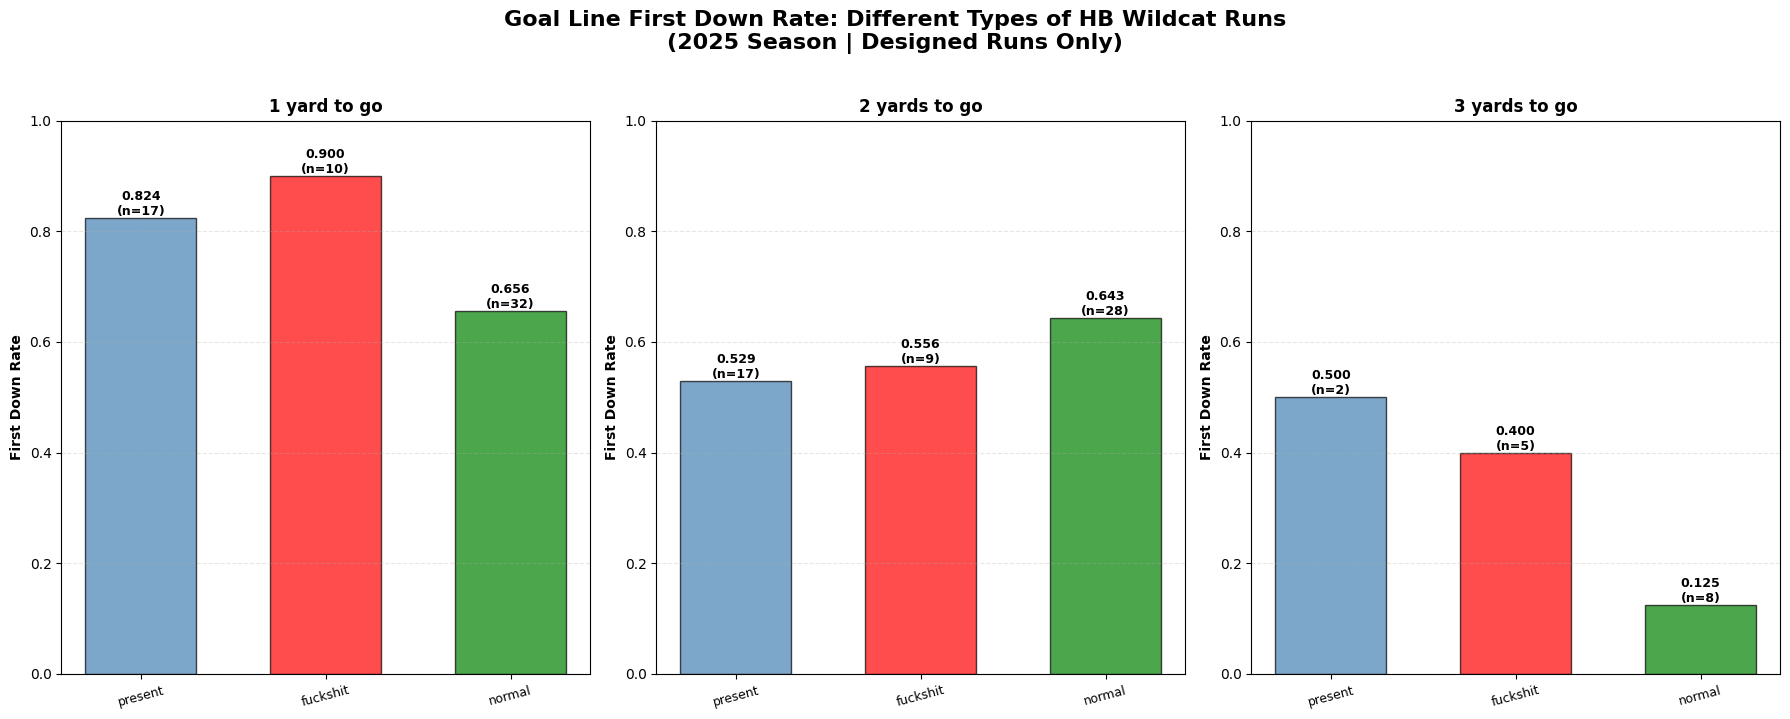

In [8]:
decisions = ['present', 'fuckshit', 'normal']
decision_colors = {'present': 'steelblue', 'fuckshit': 'red', 'normal': 'green'}

distances = [1, 2, 3]

fig, axes = plt.subplots(1, len(distances), figsize=(6 * len(distances), 7))
if len(distances) == 1:
    axes = [axes]

for ax, dist in zip(axes, distances):
    dist_df = combined_df[combined_df['distance'] == dist]
    valid_decisions = [d for d in decisions if len(dist_df[dist_df['wildcat_decision'] == d]) >= 1]

    for i, decision in enumerate(valid_decisions):
        group = dist_df[dist_df['wildcat_decision'] == decision]
        fd_rate = group['first_down_gained_numeric'].mean()
        n = len(group)

        ax.bar(i, fd_rate, width=0.6, color=decision_colors[decision], alpha=0.7, edgecolor='black')
        ax.text(i, fd_rate, f"{fd_rate:.3f}\n(n={n})",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(range(len(valid_decisions)))
    ax.set_xticklabels(valid_decisions, rotation=15, fontsize=9)
    ax.set_title(f'{dist} yard{"s" if dist > 1 else ""} to go', fontweight='bold', fontsize=12)
    ax.set_ylabel('First Down Rate', fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Goal Line First Down Rate: Different Types of HB Wildcat Runs\n(2025 Season | Designed Runs Only)',
             fontsize=16, fontweight='bold', x=0.5, y=1.02)
plt.tight_layout()
plt.show()